In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Understanding the raw structure

In [2]:
# load the dataset

star_wars = pd.read_csv("C:/Users/Hp/Downloads/StarWars.csv", encoding="latin1") 

star_wars.head()

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,...,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


In [3]:
# view each column's name, number of non_null values and data type 

star_wars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187 entries, 0 to 1186
Data columns (total 38 columns):
 #   Column                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                         --------------  -----  
 0   RespondentID                                                                                                                                   1186 non-null   float64
 1   Have you seen any of the 6 films in the Star Wars franchise?                                                                                   1187 non-null   object 
 2   Do you consider yourself to be a fan of the Star Wars film franchise?                                                                          837 non-null    object 
 3   Which of the following Star 

In [4]:
star_wars.columns

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'Which of the following Star Wars films have you seen? Please select all that apply.',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expan

In [5]:
# return the number of rows and columns in the dataset

star_wars.shape

(1187, 38)

The dataset contain 1187 rows and 38 columns. Some column names are too long while other are "unnamed" giving need for a cleaning operation to be carried out on the column names. The first row, star_wars.iloc[0], contains values that are not related to other values in subsequent rows. It was observed that the first row was a second header; it contain values that complement the header. 
Therefore, a cleaning operation need to be carried out to merge the relevant complementary details on the first row to their respective column name

## Data Cleaning

In [6]:
# The seen columns

print("Row 0:")
print(star_wars.iloc[0][3:9].tolist()) 

Row 0:
['Star Wars: Episode I  The Phantom Menace', 'Star Wars: Episode II  Attack of the Clones', 'Star Wars: Episode III  Revenge of the Sith', 'Star Wars: Episode IV  A New Hope', 'Star Wars: Episode V The Empire Strikes Back', 'Star Wars: Episode VI Return of the Jedi']


These are the Star Wars movies from Episode I to VI. These are meant to be in the header, asking participants of the survey if they have seen the movies.

In [7]:
# Create list of shortened movie title for seen movies

sw_episode = [
    "Episode I",
    "Episode II",
    "Episode III",
    "Episode IV",
    "Episode V",
    "Episode VI"
]

sw_episode

['Episode I',
 'Episode II',
 'Episode III',
 'Episode IV',
 'Episode V',
 'Episode VI']

In [8]:
# Return the column names as a list

star_wars.columns.to_list()

['RespondentID',
 'Have you seen any of the 6 films in the Star Wars franchise?',
 'Do you consider yourself to be a fan of the Star Wars film franchise?',
 'Which of the following Star Wars films have you seen? Please select all that apply.',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28',
 'Which character shot first?',
 'Are you familiar with the Expanded Universe?',
 'Do you consider yourself to be a fan of the Expan

In [9]:
# The seen columns to be renamed

star_wars.columns.to_list()[3:9]

['Which of the following Star Wars films have you seen? Please select all that apply.',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8']

In [10]:
# Rename the seen columns 

for col, film in zip(star_wars.columns.to_list()[3:9], sw_episode):
    star_wars.rename(columns = {col: "seen: "+ film}, inplace = True)
    
star_wars.columns[3:9]

Index(['seen: Episode I', 'seen: Episode II', 'seen: Episode III',
       'seen: Episode IV', 'seen: Episode V', 'seen: Episode VI'],
      dtype='object')

In [11]:
star_wars.head(2)

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,...,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic


In [12]:
star_wars.columns

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'seen: Episode I', 'seen: Episode II', 'seen: Episode III',
       'seen: Episode IV', 'seen: Episode V', 'seen: Episode VI',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expanded Universe?',
       'Do you conside

In [13]:
# Return the ranking columns as a list

star_wars.columns[9:15].to_list()

['Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14']

In [14]:
# Rename the ranking columns

for col, film in zip(star_wars.columns[9:15].to_list(), sw_episode):
    star_wars.rename(columns = {col: "rank: " + film}, inplace = True)
star_wars.columns[9:15]

Index(['rank: Episode I', 'rank: Episode II', 'rank: Episode III',
       'rank: Episode IV', 'rank: Episode V', 'rank: Episode VI'],
      dtype='object')

In [15]:
star_wars.iloc[:5, 9:15]

,rank: Episode I,rank: Episode II,rank: Episode III,rank: Episode IV,rank: Episode V,rank: Episode VI
0,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi
1,3,2,1,4,5,6
2,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2,3,4,5,6
4,5,6,1,2,4,3


In [16]:
star_wars.iloc[0][15:]

Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.                Han Solo
Unnamed: 16                                                                                                             Luke Skywalker
Unnamed: 17                                                                                                       Princess Leia Organa
Unnamed: 18                                                                                                           Anakin Skywalker
Unnamed: 19                                                                                                             Obi Wan Kenobi
Unnamed: 20                                                                                                          Emperor Palpatine
Unnamed: 21                                                                                                                Darth Vader
Unnamed: 22                                            

In [17]:
# Return the favourite character columns as a list

star_wars.columns[15:29].to_list()

['Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'Unnamed: 26',
 'Unnamed: 27',
 'Unnamed: 28']

In [18]:
# Return a list of favourite characters

fav_char = star_wars.iloc[0][15:29].to_list()

fav_char

['Han Solo',
 'Luke Skywalker',
 'Princess Leia Organa',
 'Anakin Skywalker',
 'Obi Wan Kenobi',
 'Emperor Palpatine',
 'Darth Vader',
 'Lando Calrissian',
 'Boba Fett',
 'C-3P0',
 'R2 D2',
 'Jar Jar Binks',
 'Padme Amidala',
 'Yoda']

In [19]:
# Rename favourite character columns

for col, char in zip(star_wars.columns[15:29].to_list(), fav_char):
    star_wars.rename(columns = {col: "view on: "+ char}, inplace = True)
star_wars.columns[15:29]

Index(['view on: Han Solo', 'view on: Luke Skywalker',
       'view on: Princess Leia Organa', 'view on: Anakin Skywalker',
       'view on: Obi Wan Kenobi', 'view on: Emperor Palpatine',
       'view on: Darth Vader', 'view on: Lando Calrissian',
       'view on: Boba Fett', 'view on: C-3P0', 'view on: R2 D2',
       'view on: Jar Jar Binks', 'view on: Padme Amidala', 'view on: Yoda'],
      dtype='object')

In [20]:
star_wars.iloc[:5, 15: 29]

,view on: Han Solo,view on: Luke Skywalker,view on: Princess Leia Organa,view on: Anakin Skywalker,view on: Obi Wan Kenobi,view on: Emperor Palpatine,view on: Darth Vader,view on: Lando Calrissian,view on: Boba Fett,view on: C-3P0,view on: R2 D2,view on: Jar Jar Binks,view on: Padme Amidala,view on: Yoda
0,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda
1,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
4,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably


In [21]:
star_wars.columns.to_list()

['RespondentID',
 'Have you seen any of the 6 films in the Star Wars franchise?',
 'Do you consider yourself to be a fan of the Star Wars film franchise?',
 'seen: Episode I',
 'seen: Episode II',
 'seen: Episode III',
 'seen: Episode IV',
 'seen: Episode V',
 'seen: Episode VI',
 'rank: Episode I',
 'rank: Episode II',
 'rank: Episode III',
 'rank: Episode IV',
 'rank: Episode V',
 'rank: Episode VI',
 'view on: Han Solo',
 'view on: Luke Skywalker',
 'view on: Princess Leia Organa',
 'view on: Anakin Skywalker',
 'view on: Obi Wan Kenobi',
 'view on: Emperor Palpatine',
 'view on: Darth Vader',
 'view on: Lando Calrissian',
 'view on: Boba Fett',
 'view on: C-3P0',
 'view on: R2 D2',
 'view on: Jar Jar Binks',
 'view on: Padme Amidala',
 'view on: Yoda',
 'Which character shot first?',
 'Are you familiar with the Expanded Universe?',
 'Do you consider yourself to be a fan of the Expanded Universe?\x8cæ',
 'Do you consider yourself to be a fan of the Star Trek franchise?',
 'Gender',


In [22]:
# Rename other long column names

star_wars.rename(columns= {'Have you seen any of the 6 films in the Star Wars franchise?': 'Seen any of the 6 Star Wars films?', 
                           'Do you consider yourself to be a fan of the Star Wars film franchise?': 'A fan of the Star Wars franchise?',
                           'Are you familiar with the Expanded Universe?': 'Familiar with the Expanded Universe?',
                           'Do you consider yourself to be a fan of the Expanded Universe?\x8cæ': 'A fan of the Expanded Universe?',
                           'Do you consider yourself to be a fan of the Star Trek franchise?':'A fan of the Star Trek franchise?'}, inplace = True)

star_wars.columns.to_list()

['RespondentID',
 'Seen any of the 6 Star Wars films?',
 'A fan of the Star Wars franchise?',
 'seen: Episode I',
 'seen: Episode II',
 'seen: Episode III',
 'seen: Episode IV',
 'seen: Episode V',
 'seen: Episode VI',
 'rank: Episode I',
 'rank: Episode II',
 'rank: Episode III',
 'rank: Episode IV',
 'rank: Episode V',
 'rank: Episode VI',
 'view on: Han Solo',
 'view on: Luke Skywalker',
 'view on: Princess Leia Organa',
 'view on: Anakin Skywalker',
 'view on: Obi Wan Kenobi',
 'view on: Emperor Palpatine',
 'view on: Darth Vader',
 'view on: Lando Calrissian',
 'view on: Boba Fett',
 'view on: C-3P0',
 'view on: R2 D2',
 'view on: Jar Jar Binks',
 'view on: Padme Amidala',
 'view on: Yoda',
 'Which character shot first?',
 'Familiar with the Expanded Universe?',
 'A fan of the Expanded Universe?',
 'A fan of the Star Trek franchise?',
 'Gender',
 'Age',
 'Household Income',
 'Education',
 'Location (Census Region)']

In [23]:
star_wars

,RespondentID,Seen any of the 6 Star Wars films?,A fan of the Star Wars franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,rank: Episode I,...,view on: Yoda,Which character shot first?,Familiar with the Expanded Universe?,A fan of the Expanded Universe?,A fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,...,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1182,3.288389e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,Han,No,NaN,Yes,Female,18-29,"$0 - $24,999",Some college or Associate degree,East North Central
1183,3.288379e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,I don't understand this question,No,NaN,Yes,Female,30-44,"$50,000 - $99,999",Bachelor degree,Mountain
1184,3.288375e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Female,30-44,"$50,000 - $99,999",Bachelor degree,Middle Atlantic
1185,3.288373e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,Han,No,NaN,Yes,Female,45-60,"$100,000 - $149,999",Some college or Associate degree,East North Central


In [24]:
# Delete the first row row[0]

star_wars = star_wars.drop(index = 0)

In [25]:
star_wars.head(3)

,RespondentID,Seen any of the 6 Star Wars films?,A fan of the Star Wars franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,rank: Episode I,...,view on: Yoda,Which character shot first?,Familiar with the Expanded Universe?,A fan of the Expanded Universe?,A fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central


The data cleaning operation has been carried out on column renaming. The columns now have shorter column names, show the seen movies, the ranked movies and favourite characters  

The values in the seen column are the names of the movies. This can be better structured leaving the values as True or False. True represents that the movie has been seen while False represents the reverse.

In [26]:
star_wars

,RespondentID,Seen any of the 6 Star Wars films?,A fan of the Star Wars franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,rank: Episode I,...,view on: Yoda,Which character shot first?,Familiar with the Expanded Universe?,A fan of the Expanded Universe?,A fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1182,3.288389e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,Han,No,NaN,Yes,Female,18-29,"$0 - $24,999",Some college or Associate degree,East North Central
1183,3.288379e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,I don't understand this question,No,NaN,Yes,Female,30-44,"$50,000 - $99,999",Bachelor degree,Mountain
1184,3.288375e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Female,30-44,"$50,000 - $99,999",Bachelor degree,Middle Atlantic
1185,3.288373e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,Han,No,NaN,Yes,Female,45-60,"$100,000 - $149,999",Some college or Associate degree,East North Central


In [27]:
# Clean the seen columns

for col in star_wars.iloc[:, 3:9]:
    star_wars[col] = star_wars[col].notnull()
star_wars.iloc[:, 3:9]

,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI
1,True,True,True,True,True,True
2,False,False,False,False,False,False
3,True,True,True,False,False,False
4,True,True,True,True,True,True
5,True,True,True,True,True,True
...,...,...,...,...,...,...
1182,True,True,True,True,True,True
1183,True,True,True,True,True,True
1184,False,False,False,False,False,False
1185,True,True,True,True,True,True


In [28]:
star_wars.head(10)

,RespondentID,Seen any of the 6 Star Wars films?,A fan of the Star Wars franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,rank: Episode I,...,view on: Yoda,Which character shot first?,Familiar with the Expanded Universe?,A fan of the Expanded Universe?,A fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1,3.292880e+09,Yes,Yes,True,True,True,True,True,True,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,False,False,False,False,False,False,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,True,True,True,False,False,False,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,True,True,True,True,True,True,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,Yes,Yes,True,True,True,True,True,True,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
6,3.292719e+09,Yes,Yes,True,True,True,True,True,True,1,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic
7,3.292685e+09,Yes,Yes,True,True,True,True,True,True,6,...,Very favorably,Han,Yes,No,No,Male,18-29,NaN,High school degree,East North Central
8,3.292664e+09,Yes,Yes,True,True,True,True,True,True,4,...,Very favorably,Han,No,NaN,Yes,Male,18-29,NaN,High school degree,South Atlantic
9,3.292654e+09,Yes,Yes,True,True,True,True,True,True,5,...,Somewhat favorably,Han,No,NaN,No,Male,18-29,"$0 - $24,999",Some college or Associate degree,South Atlantic
10,3.292640e+09,Yes,No,False,True,False,False,False,False,1,...,Very favorably,I don't understand this question,No,NaN,No,Male,18-29,"$25,000 - $49,999",Some college or Associate degree,Pacific


The most crucial response to this analysis is if the respondent has seen any of the 6 star wars movies. If the respondent hasnt seen any, their response is not needed for this analysis. So a filtering operation should be carried out to this effect

In [29]:
# Filter respondent that has seen any star wars movie

seen_star_wars = star_wars[star_wars["Seen any of the 6 Star Wars films?"] == "Yes"].copy()

seen_star_wars

,RespondentID,Seen any of the 6 Star Wars films?,A fan of the Star Wars franchise?,seen: Episode I,seen: Episode II,seen: Episode III,seen: Episode IV,seen: Episode V,seen: Episode VI,rank: Episode I,...,view on: Yoda,Which character shot first?,Familiar with the Expanded Universe?,A fan of the Expanded Universe?,A fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
1,3.292880e+09,Yes,Yes,True,True,True,True,True,True,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
3,3.292765e+09,Yes,No,True,True,True,False,False,False,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,True,True,True,True,True,True,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,Yes,Yes,True,True,True,True,True,True,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
6,3.292719e+09,Yes,Yes,True,True,True,True,True,True,1,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,3.288390e+09,Yes,Yes,True,True,True,True,True,True,3,...,Very favorably,Han,No,NaN,No,Female,45-60,"$0 - $24,999",Some college or Associate degree,Pacific
1182,3.288389e+09,Yes,Yes,True,True,True,True,True,True,5,...,Very favorably,Han,No,NaN,Yes,Female,18-29,"$0 - $24,999",Some college or Associate degree,East North Central
1183,3.288379e+09,Yes,Yes,True,True,True,True,True,True,4,...,Very favorably,I don't understand this question,No,NaN,Yes,Female,30-44,"$50,000 - $99,999",Bachelor degree,Mountain
1185,3.288373e+09,Yes,Yes,True,True,True,True,True,True,4,...,Very favorably,Han,No,NaN,Yes,Female,45-60,"$100,000 - $149,999",Some college or Associate degree,East North Central


In [30]:
seen_star_wars.shape

(936, 38)

In [31]:
star_wars.shape

(1186, 38)

1186 respondents took part in this survey, while 936 of them have seen at least 1 star wars movie. 250 respondents have not seen any star wars movie, therefore, they are not needed for this analysis.

## EDA

### Movie Viewership

In [32]:
viewership_percentage = seen_star_wars.iloc[:, 3:9].mean().sort_values(ascending = False)

viewership_percentage

seen: Episode V      0.809829
seen: Episode VI     0.788462
seen: Episode I      0.719017
seen: Episode IV     0.648504
seen: Episode II     0.610043
seen: Episode III    0.587607
dtype: float64

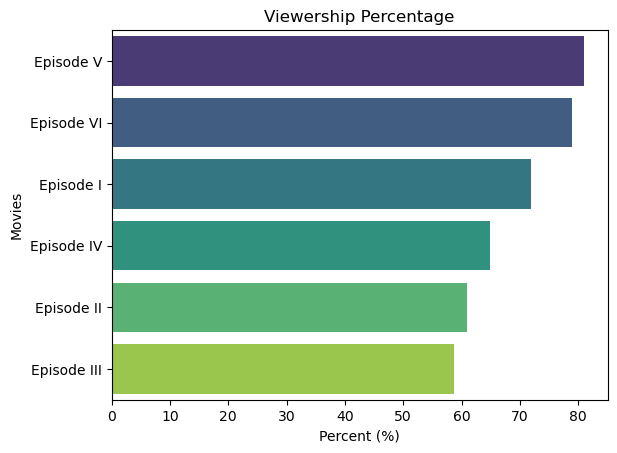

In [33]:
viewership_percentage.index = viewership_percentage.index.str.replace("seen: ", "")

sns.barplot(x= viewership_percentage.values * 100, y=viewership_percentage.index, hue = viewership_percentage.index, palette="viridis")
plt.title("Viewership Percentage")
plt.ylabel("Movies")
plt.xlabel("Percent (%)")
plt.show()

Episode V is the most seen movie in the franchise with 81% of the respondents, closely followed by Episode VI with 79% of the respondent. A pattern was observed here; even though Episode I has the third most viewership, the original movies (Episdoe IV to VI) has more viewership than the prequels (Episode I to III)

### Movie Ranking

In [34]:
seen_star_wars.iloc[:, 9:15].info()

<class 'pandas.core.frame.DataFrame'>
Index: 936 entries, 1 to 1186
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rank: Episode I    835 non-null    object
 1   rank: Episode II   836 non-null    object
 2   rank: Episode III  835 non-null    object
 3   rank: Episode IV   836 non-null    object
 4   rank: Episode V    836 non-null    object
 5   rank: Episode VI   836 non-null    object
dtypes: object(6)
memory usage: 51.2+ KB


A numerical operation is to be carried out on the rank columns but the datatype for the ranks is object and not in any numerical form

In [35]:
# Convert rank columns to numeric datatype 

for col in seen_star_wars.iloc[:, 9:15]:
    seen_star_wars[col] = pd.to_numeric(seen_star_wars[col])

seen_star_wars.iloc[:, 9:15].info()

<class 'pandas.core.frame.DataFrame'>
Index: 936 entries, 1 to 1186
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rank: Episode I    835 non-null    float64
 1   rank: Episode II   836 non-null    float64
 2   rank: Episode III  835 non-null    float64
 3   rank: Episode IV   836 non-null    float64
 4   rank: Episode V    836 non-null    float64
 5   rank: Episode VI   836 non-null    float64
dtypes: float64(6)
memory usage: 51.2 KB


In [36]:
movie_ranking = seen_star_wars.iloc[:, 9:15].mean().sort_values()

movie_ranking

rank: Episode V      2.513158
rank: Episode VI     3.047847
rank: Episode IV     3.272727
rank: Episode I      3.732934
rank: Episode II     4.087321
rank: Episode III    4.341317
dtype: float64

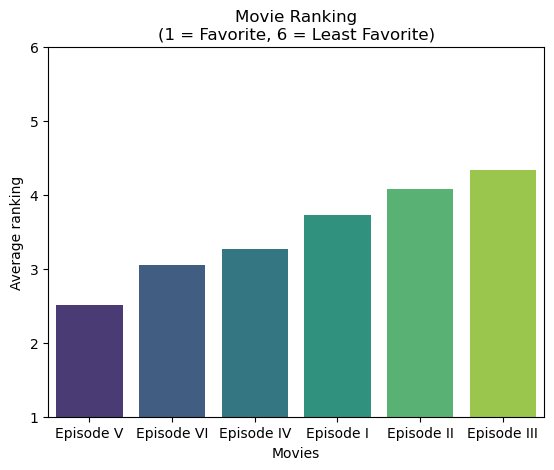

In [37]:
movie_ranking.index = movie_ranking.index.str.replace("rank: ", "")

sns.barplot(x = movie_ranking.index, y = movie_ranking.values, hue = movie_ranking.index, palette="viridis")
plt.xlabel("Movies")
plt.ylabel("Average ranking")
plt.title("Movie Ranking\n(1 = Favorite, 6 = Least Favorite)")
plt.ylim(1, 6)
plt.show()


Episode V is the favourite of the 6 movies, followed by Episode VI and Episode IV. This reveals a trend that movie viewership also show. The original movies -- episode IV to VI -- not only are they the most viewed, they are also the fan's favourites.

### Character Favourability

In [38]:
# Set numercal values to replace the favourability rating

fav_ind = {"Very favorably" : 2, "Somewhat favorably" : 1, "Neither favorably nor unfavorably (neutral)" : 0, 
           "Somewhat unfavorably" : -1, "Very unfavorably" : -2, "Unfamiliar (N/A)" : np.nan}

fav_ind

{'Very favorably': 2,
 'Somewhat favorably': 1,
 'Neither favorably nor unfavorably (neutral)': 0,
 'Somewhat unfavorably': -1,
 'Very unfavorably': -2,
 'Unfamiliar (N/A)': nan}

In [39]:
favourite_characters = seen_star_wars.iloc[:, 15:29]

favourite_characters.head()

,view on: Han Solo,view on: Luke Skywalker,view on: Princess Leia Organa,view on: Anakin Skywalker,view on: Obi Wan Kenobi,view on: Emperor Palpatine,view on: Darth Vader,view on: Lando Calrissian,view on: Boba Fett,view on: C-3P0,view on: R2 D2,view on: Jar Jar Binks,view on: Padme Amidala,view on: Yoda
1,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
3,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
4,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
5,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably
6,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Neither favorably nor unfavorably (neutral),Very favorably,Neither favorably nor unfavorably (neutral),Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably


In [40]:
# Replace the favourability ratings with the numerical values

favourite_characters = favourite_characters.replace(fav_ind)

favourite_characters

C:\Users\Hp\AppData\Local\Temp\ipykernel_13172\760279383.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  favourite_characters = favourite_characters.replace(fav_ind)


,view on: Han Solo,view on: Luke Skywalker,view on: Princess Leia Organa,view on: Anakin Skywalker,view on: Obi Wan Kenobi,view on: Emperor Palpatine,view on: Darth Vader,view on: Lando Calrissian,view on: Boba Fett,view on: C-3P0,view on: R2 D2,view on: Jar Jar Binks,view on: Padme Amidala,view on: Yoda
1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,2.0,2.0,2.0,2.0
3,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,-1.0,2.0,2.0,2.0,2.0,2.0
5,2.0,1.0,1.0,-1.0,2.0,-2.0,1.0,0.0,2.0,1.0,1.0,-2.0,1.0,1.0
6,2.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1181,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0
1182,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0
1183,2.0,1.0,2.0,-1.0,2.0,0.0,-2.0,1.0,NaN,1.0,2.0,-1.0,-1.0,2.0
1185,2.0,0.0,2.0,2.0,2.0,0.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0


In [41]:
char_favourability = favourite_characters.mean().sort_values(ascending=False)

char_favourability

view on: Han Solo                1.671990
view on: Obi Wan Kenobi          1.632426
view on: Yoda                    1.629902
view on: Luke Skywalker          1.580606
view on: R2 D2                   1.569512
view on: Princess Leia Organa    1.555286
view on: C-3P0                   1.403941
view on: Anakin Skywalker        0.775616
view on: Lando Calrissian        0.636905
view on: Padme Amidala           0.604615
view on: Darth Vader             0.479167
view on: Boba Fett               0.357353
view on: Emperor Palpatine       0.071429
view on: Jar Jar Binks          -0.219101
dtype: float64

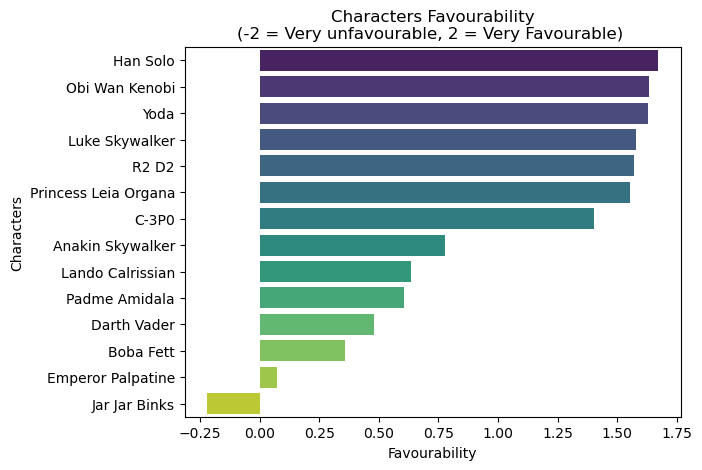

In [42]:
char_favourability.index = char_favourability.index.str.replace("view on: ", "")

sns.barplot(x = char_favourability.values, y = char_favourability.index, hue = char_favourability.index, palette="viridis")
plt.xlabel("Favourability")
plt.ylabel("Characters")
plt.title("Characters Favourability\n(-2 = Very unfavourable, 2 = Very Favourable) ")
plt.show()

With Han Solo been the fan's favourite closely followed by Obi Wan Kenobi and Yoda, only Jar Jar Binks fall in the unfavourable range with all others characters in the favourable range.

### Demography analysis

In [43]:
seen_star_wars.iloc[:, 33:]

,Gender,Age,Household Income,Education,Location (Census Region)
1,Male,18-29,NaN,High school degree,South Atlantic
3,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
6,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic
...,...,...,...,...,...
1181,Female,45-60,"$0 - $24,999",Some college or Associate degree,Pacific
1182,Female,18-29,"$0 - $24,999",Some college or Associate degree,East North Central
1183,Female,30-44,"$50,000 - $99,999",Bachelor degree,Mountain
1185,Female,45-60,"$100,000 - $149,999",Some college or Associate degree,East North Central


#### Viewership by Gender

In [44]:
viewership_by_gender = seen_star_wars.groupby(["Gender"])[['seen: Episode I',
       'seen: Episode II', 'seen: Episode III', 'seen: Episode IV',
       'seen: Episode V', 'seen: Episode VI',]].mean()
viewership_by_gender.columns = viewership_by_gender.columns.str.replace("seen: ", "")

viewership_by_gender

,Episode I,Episode II,Episode III,Episode IV,Episode V,Episode VI
Gender,,,,,,
Female,0.750630,0.596977,0.559194,0.642317,0.889169,0.851385
Male,0.853428,0.763593,0.749409,0.808511,0.926714,0.914894


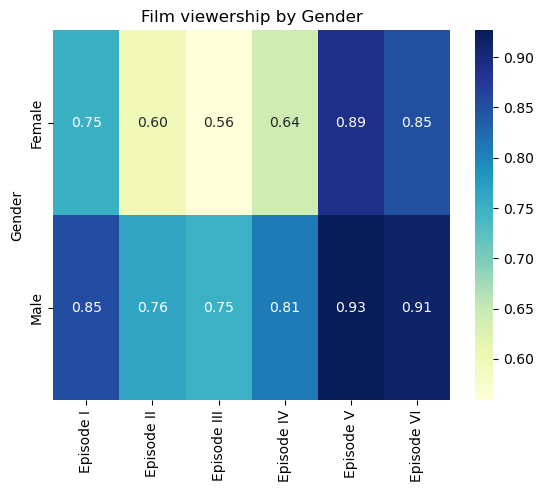

In [45]:
sns.heatmap(viewership_by_gender,
    annot=True,    
    fmt=".2f",   
    cmap="YlGnBu"
)
plt.title("Film viewership by Gender")
plt.show()

The male gender recorded higher viewership than the female gender. The male viewership range from 93% (Episode VI) to 75% (Episode III) while feamle viewership range from 89% (Episode V) to 56% (Episode III)

#### Viewership by Age

In [46]:
seen_star_wars["Age"].value_counts().sort_values(ascending = False)

Age
45-60    240
30-44    207
> 60     193
18-29    180
Name: count, dtype: int64

In [47]:
viewership_by_age = seen_star_wars.groupby(["Age"])[['seen: Episode I',
       'seen: Episode II', 'seen: Episode III', 'seen: Episode IV',
       'seen: Episode V', 'seen: Episode VI',]].mean()

viewership_by_age.columns = viewership_by_age.columns.str.replace("seen: ", "")
viewership_by_age

,Episode I,Episode II,Episode III,Episode IV,Episode V,Episode VI
Age,,,,,,
18-29,0.888889,0.822222,0.805556,0.844444,0.888889,0.888889
30-44,0.845411,0.763285,0.734300,0.850242,0.951691,0.951691
45-60,0.754167,0.616667,0.591667,0.687500,0.916667,0.875000
> 60,0.740933,0.549223,0.518135,0.538860,0.870466,0.818653


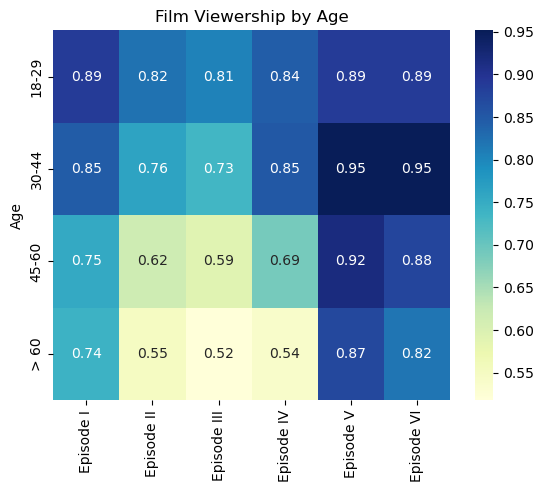

In [48]:
sns.heatmap(
    viewership_by_age,
    annot = True,
    fmt = ".2f",
    cmap = "YlGnBu"
)
plt.title("Film Viewership by Age")
plt.show()

The older viewers (from 45 above) engaged with the original movies and didnt really engage the prequels. The younger viewers (18 - 44) also engage the original movies strongly but their engagement didnt really drop off with the prequels.

#### Viewership by Income

In [49]:
seen_star_wars["Household Income"].value_counts()

Household Income
$50,000 - $99,999      238
$25,000 - $49,999      147
$100,000 - $149,999    115
$0 - $24,999            98
$150,000+               77
Name: count, dtype: int64

In [50]:
viewership_by_income = seen_star_wars.groupby(["Household Income"])[['seen: Episode I',
       'seen: Episode II', 'seen: Episode III', 'seen: Episode IV',
       'seen: Episode V', 'seen: Episode VI',]].mean()

viewership_by_income.columns = viewership_by_income.columns.str.replace("seen: ", "")
viewership_by_income

,Episode I,Episode II,Episode III,Episode IV,Episode V,Episode VI
Household Income,,,,,,
"$0 - $24,999",0.765306,0.673469,0.653061,0.744898,0.928571,0.877551
"$100,000 - $149,999",0.756522,0.652174,0.634783,0.721739,0.930435,0.921739
"$150,000+",0.883117,0.701299,0.701299,0.792208,0.922078,0.922078
"$25,000 - $49,999",0.775510,0.639456,0.619048,0.659864,0.877551,0.843537
"$50,000 - $99,999",0.831933,0.697479,0.659664,0.731092,0.907563,0.861345


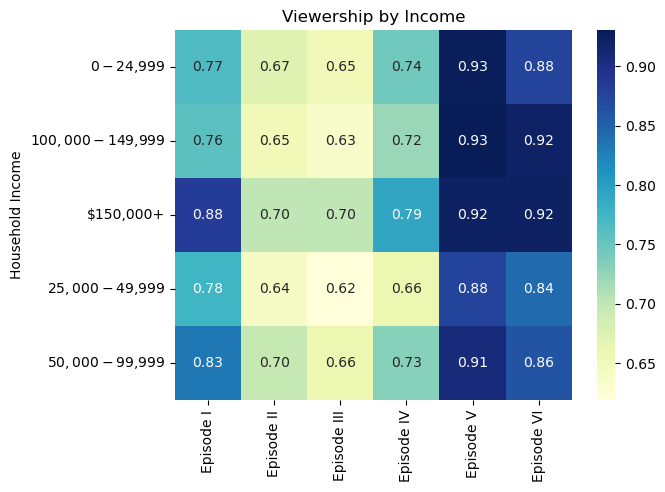

In [51]:
sns.heatmap(
    viewership_by_income,
    annot=True,
    fmt = ".2f",
    cmap="YlGnBu"
)
plt.title("Viewership by Income")
plt.show()

### Who shot first?

BACKGROUND.\
"Who shot first?" is essentially a fan loyalty test.\
In the original 1977 release of Episode IV, Han Solo shoots a bounty hunter named Greedo in a cantina — and Han shoots first, unprovoked.\
In George Lucas's 1997 re-release, he edited the scene so Greedo shoots first and Han shoots in self-defence. Fans were outraged.\
Someone who answers "Han" has seen the original and cares about the lore. Someone who says "I don't understand this question" is likely a casual viewer or non-fan.

In [52]:
seen_star_wars.groupby(['Which character shot first?'])["A fan of the Star Wars franchise?"].value_counts()

Which character shot first?       A fan of the Star Wars franchise?
Greedo                            Yes                                  151
                                  No                                    46
Han                               Yes                                  268
                                  No                                    57
I don't understand this question  No                                   180
                                  Yes                                  126
Name: count, dtype: int64

In [53]:
pd.crosstab(seen_star_wars['Which character shot first?'], seen_star_wars["A fan of the Star Wars franchise?"])

A fan of the Star Wars franchise?,No,Yes
Which character shot first?,,
Greedo,46,151
Han,57,268
I don't understand this question,180,126


<Axes: xlabel='Which character shot first?'>

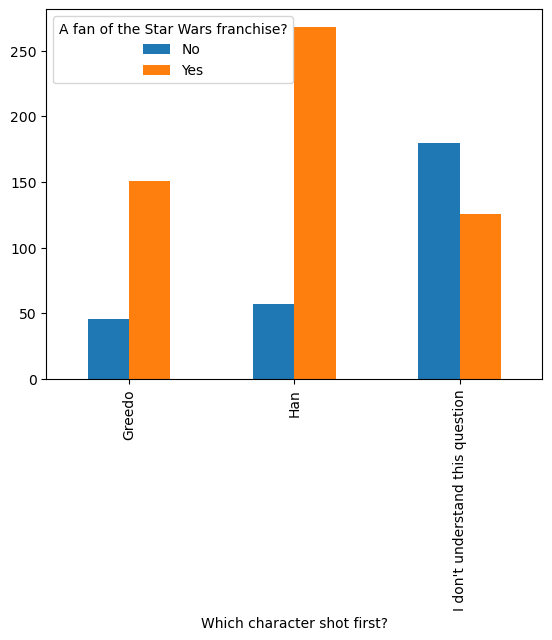

In [54]:
pd.crosstab(seen_star_wars['Which character shot first?'], seen_star_wars["A fan of the Star Wars franchise?"]).plot(kind = "bar")

Out of 325 people who said "Han", 268 are fans. That's about 82%. Out of 306 who said "I don't understand", 126 are fans — only 41%.